In [43]:
# ============================================================
# CELL 1: Import & Load Session
# ============================================================
import numpy as np
import pickle
import random
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score,
                            confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load session
with open('session/session_preprocessing.pkl', 'rb') as f:
    sv = pickle.load(f)

le               = sv['le']
scaler           = sv['scaler']
num_classes      = sv['num_classes']
SEED             = sv['SEED']
ecocrop_gaussian = sv['ecocrop_gaussian']
physics_features = sv['physics_features']

X_train          = sv['X_train']
X_val            = sv['X_val']
X_test           = sv['X_test']
X_train_scaled   = sv['X_train_scaled']
X_val_scaled     = sv['X_val_scaled']
X_test_scaled    = sv['X_test_scaled']
y_train_oh       = sv['y_train_oh']
y_val_oh         = sv['y_val_oh']
y_test_oh        = sv['y_test_oh']
y_test           = sv['y_test']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print("✅ Session loaded")
print(f"   Physics features : {physics_features}")
print(f"   SEED             : {SEED}")

✅ Session loaded
   Physics features : ['temperature', 'ph']
   SEED             : 42


In [44]:
# ============================================================
# CELL 2: Konfigurasi
# ============================================================

INPUT_DIM  = 7
HIDDEN_DIM = 32
OUTPUT_DIM = num_classes  # 22

EPOCHS     = 100
BATCH_SIZE = 32
LR         = 0.001

TEMP_IDX   = 3
PH_IDX     = 5

print("✅ Konfigurasi:")
print(f"   Arsitektur : {INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}")
print(f"   Epochs     : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : {LR}")
print(f"   ε inisialisasi: exp(0) = 1.0 untuk keduanya")

✅ Konfigurasi:
   Arsitektur : 7→32→22
   Epochs     : 100
   Batch size : 32
   LR         : 0.001
   ε inisialisasi: exp(0) = 1.0 untuk keduanya


In [45]:
# ============================================================
# CELL 3: Physics Constraint Tensors
# (sama persis dengan Fixed-PINN)
# ============================================================

crop_names   = list(le.classes_)
scaler_mean  = scaler.mean_
scaler_std   = scaler.scale_

physics_mu    = np.zeros((22, 2))
physics_sigma = np.zeros((22, 2))

for i, crop in enumerate(crop_names):
    physics_mu[i, 0]    = ecocrop_gaussian[crop]['temperature'][0]
    physics_mu[i, 1]    = ecocrop_gaussian[crop]['ph'][0]
    physics_sigma[i, 0] = ecocrop_gaussian[crop]['temperature'][1]
    physics_sigma[i, 1] = ecocrop_gaussian[crop]['ph'][1]

feat_indices         = [TEMP_IDX, PH_IDX]
physics_mu_scaled    = (physics_mu - scaler_mean[feat_indices]) \
                        / scaler_std[feat_indices]
physics_sigma_scaled = physics_sigma / scaler_std[feat_indices]

physics_mu_tf    = tf.constant(physics_mu_scaled,    dtype=tf.float32)
physics_sigma_tf = tf.constant(physics_sigma_scaled, dtype=tf.float32)

rice_idx = crop_names.index('rice')
print("✅ Physics constraint tensors siap")
print(f"   Rice temp scaled: μ={physics_mu_scaled[rice_idx,0]:.4f}, "
      f"σ={physics_sigma_scaled[rice_idx,0]:.4f}")
print(f"   Rice pH scaled  : μ={physics_mu_scaled[rice_idx,1]:.4f}, "
      f"σ={physics_sigma_scaled[rice_idx,1]:.4f}")

✅ Physics constraint tensors siap
   Rice temp scaled: μ=-0.1138, σ=0.3253
   Rice pH scaled  : μ=-0.2833, σ=0.3222


In [46]:
# ============================================================
# CELL 4: Loss Functions
# ============================================================

def data_loss_fn(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    return -tf.reduce_mean(
        tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1)
    )

def physics_loss_fn(X_batch_scaled, y_pred, y_true_oh):
    temp = X_batch_scaled[:, TEMP_IDX:TEMP_IDX+1]
    ph   = X_batch_scaled[:, PH_IDX:PH_IDX+1]

    mu_t  = physics_mu_tf[:, 0]
    mu_p  = physics_mu_tf[:, 1]
    sig_t = physics_sigma_tf[:, 0]
    sig_p = physics_sigma_tf[:, 1]

    temp_score = tf.exp(
        -tf.square(temp - mu_t) / (2 * tf.square(sig_t))
    )
    ph_score   = tf.exp(
        -tf.square(ph - mu_p) / (2 * tf.square(sig_p))
    )

    env_score    = temp_score * ph_score
    env_score_gt = tf.reduce_sum(y_true_oh * env_score, axis=1)
    crop_prob_gt = tf.reduce_sum(y_true_oh * y_pred,    axis=1)
    
    # Menggunakan tf.maximum sesuai proposal Anda
    komponen_1 = (1.0 - crop_prob_gt) * env_score_gt
    komponen_2 = crop_prob_gt * (1.0 - env_score_gt)
    physics_loss = tf.reduce_mean(tf.maximum(komponen_1, komponen_2))
    # rumus jumlah
    # komponen_underconfidence = (1.0 - crop_prob_gt) * env_score_gt
    # komponen_overconfidence = crop_prob_gt * (1.0 - env_score_gt)
    # physics_loss  = tf.reduce_mean(komponen_underconfidence + komponen_overconfidence)
    # # Gunasekaran
    # physics_loss = tf.reduce_mean(
    #     (1 - crop_prob_gt) * env_score_gt
    # )
    return physics_loss, env_score_gt, crop_prob_gt

# ============================================================
# lbPINN Total Loss
# Rujukan: BAB 3 hal 52-53, Xiang et al. (2021)
#
# L_total = 1/2ε²_d × L_data +
#           1/2ε²_p × L_physics +
#           log(ε_d · ε_p)
#
# ε disimpan dalam log-scale:
# ε = exp(log_ε) → selalu positif
# inisialisasi log_ε = 0 → ε = exp(0) = 1.0
# ============================================================

# Parameter uncertainty (trainable)
log_eps_data    = tf.Variable(0.0, trainable=True,
                              dtype=tf.float32,
                              name='log_eps_data')
log_eps_physics = tf.Variable(0.0, trainable=True,
                              dtype=tf.float32,
                              name='log_eps_physics')

def lbpinn_total_loss(model, X_scaled, y_oh):
    """
    Hitung total loss lbPINN:
    L = 1/2ε²_d × L_data + 1/2ε²_p × L_physics + log(ε_d·ε_p)
    """
    y_pred    = model(X_scaled, training=True)
    l_data    = data_loss_fn(y_oh, y_pred)
    l_physics, _, _ = physics_loss_fn(X_scaled, y_pred, y_oh)

    eps_d = tf.exp(log_eps_data)
    eps_p = tf.exp(log_eps_physics)

    total = (
        (1 / (2 * tf.square(eps_d))) * l_data +
        (1 / (2 * tf.square(eps_p))) * l_physics +
        tf.math.log(eps_d * eps_p)
    )
    return total, l_data, l_physics, eps_d, eps_p

# Test
X_dummy = tf.constant(X_train_scaled[:32], dtype=tf.float32)
y_dummy = tf.constant(y_train_oh[:32],     dtype=tf.float32)

tf.random.set_seed(SEED)
test_model   = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(HIDDEN_DIM, activation='relu'),
    tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')
])

total, ld, lp, ed, ep = lbpinn_total_loss(test_model, X_dummy, y_dummy)

print("✅ Loss functions siap")
print(f"   L_data         : {ld.numpy():.4f}")
print(f"   L_physics      : {lp.numpy():.4f} (harus 0-1)")
print(f"   L_total        : {total.numpy():.4f}")
print(f"   ε_data   (init): {ed.numpy():.4f}")
print(f"   ε_physics(init): {ep.numpy():.4f}")
assert lp.numpy() >= 0, "❌ Physics loss negatif!"
print("\n✅ Physics loss valid")

✅ Loss functions siap
   L_data         : 3.2253
   L_physics      : 0.1333 (harus 0-1)
   L_total        : 1.6793
   ε_data   (init): 1.0000
   ε_physics(init): 1.0000

✅ Physics loss valid


In [47]:
# ============================================================
# CELL 5: Training Loop lbPINN
# ============================================================

def train_epoch_lbpinn(model, optimizer, X_scaled, y_oh,
                       batch_size, seed_offset):
    """
    Satu epoch training lbPINN
    Update θ (model) DAN ε_data, ε_physics sekaligus
    """
    n = X_scaled.shape[0]
    np.random.seed(SEED + seed_offset)
    idx      = np.random.permutation(n)
    X_scaled = X_scaled[idx]
    y_oh     = y_oh[idx]

    total_losses   = []
    data_losses    = []
    physics_losses = []
    correct        = 0

    # Semua parameter yang dioptimisasi:
    # bobot jaringan + ε_data + ε_physics
    all_vars = (model.trainable_variables +
                [log_eps_data, log_eps_physics])

    for i in range(0, n, batch_size):
        X_b = tf.constant(X_scaled[i:i+batch_size], dtype=tf.float32)
        y_b = tf.constant(y_oh[i:i+batch_size],     dtype=tf.float32)

        with tf.GradientTape() as tape:
            total, l_data, l_physics, eps_d, eps_p = \
                lbpinn_total_loss(model, X_b, y_b)

        grads = tape.gradient(total, all_vars)
        optimizer.apply_gradients(zip(grads, all_vars))

        total_losses.append(total.numpy())
        data_losses.append(l_data.numpy())
        physics_losses.append(l_physics.numpy())

        y_pred = model(X_b, training=False)
        correct += np.sum(
            np.argmax(y_pred.numpy(), axis=1) ==
            np.argmax(y_b.numpy(), axis=1)
        )

    return (np.mean(total_losses),
            np.mean(data_losses),
            np.mean(physics_losses),
            correct / n)


def evaluate_lbpinn(model, X_scaled, y_oh):
    """Evaluasi lbPINN"""
    X_tf   = tf.constant(X_scaled, dtype=tf.float32)
    y_tf   = tf.constant(y_oh,     dtype=tf.float32)

    total, l_data, l_physics, eps_d, eps_p = \
        lbpinn_total_loss(model, X_tf, y_tf)

    y_pred = model(X_tf, training=False)
    acc    = np.mean(
        np.argmax(y_pred.numpy(), axis=1) ==
        np.argmax(y_oh, axis=1)
    )
    return (total.numpy(), l_data.numpy(),
            l_physics.numpy(), acc,
            eps_d.numpy(), eps_p.numpy())


print("✅ Training loop lbPINN siap")

✅ Training loop lbPINN siap


In [48]:
# ============================================================
# CELL 6: Training lbPINN
# ============================================================

# Reset ε setiap kali training ulang
log_eps_data.assign(0.0)
log_eps_physics.assign(0.0)

tf.random.set_seed(SEED)
model_lbpinn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(HIDDEN_DIM, activation='relu'),
    tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')
])

optimizer_lb = tf.keras.optimizers.Adam(learning_rate=LR)

history = {
    'train_total'  : [], 'val_total'   : [],
    'train_data'   : [], 'val_data'    : [],
    'train_physics': [], 'val_physics' : [],
    'train_acc'    : [], 'val_acc'     : [],
    'eps_data'     : [], 'eps_physics' : []
}

# ── Cetak nilai ε SEBELUM training dimulai ──
eps_d_init = tf.exp(log_eps_data).numpy()
eps_p_init = tf.exp(log_eps_physics).numpy()
w_d_init   = 1 / (2 * eps_d_init ** 2)
w_p_init   = 1 / (2 * eps_p_init ** 2)

print("=== TRAINING lbPINN ===")
print(f"Arsitektur : {INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}")
print(f"Epochs     : {EPOCHS}")
print(f"\nInisialisasi ε (sebelum training):")
print(f"   ε_data    = {eps_d_init:.4f} → bobot efektif = {w_d_init:.4f}")
print(f"   ε_physics = {eps_p_init:.4f} → bobot efektif = {w_p_init:.4f}\n")

for epoch in range(EPOCHS):
    # Training
    tr_total, tr_data, tr_physics, tr_acc = train_epoch_lbpinn(
        model_lbpinn, optimizer_lb,
        X_train_scaled, y_train_oh,
        BATCH_SIZE, seed_offset=epoch
    )

    # Validasi
    vl_total, vl_data, vl_physics, vl_acc, eps_d, eps_p = \
        evaluate_lbpinn(model_lbpinn, X_val_scaled, y_val_oh)

    history['train_total'].append(tr_total)
    history['val_total'].append(vl_total)
    history['train_data'].append(tr_data)
    history['val_data'].append(vl_data)
    history['train_physics'].append(tr_physics)
    history['val_physics'].append(vl_physics)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['eps_data'].append(eps_d)
    history['eps_physics'].append(eps_p)

    # ── Cetak epoch 1 secara eksplisit ──
    if epoch == 0:
        print(f"Epoch   1/{EPOCHS} | "
              f"total: {tr_total:.4f} | "
              f"data: {tr_data:.4f} | "
              f"physics: {tr_physics:.4f} | "
              f"val_acc: {vl_acc:.4f} | "
              f"ε_d: {eps_d:.4f} | "
              f"ε_p: {eps_p:.4f}")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"total: {tr_total:.4f} | "
              f"data: {tr_data:.4f} | "
              f"physics: {tr_physics:.4f} | "
              f"val_acc: {vl_acc:.4f} | "
              f"ε_d: {eps_d:.4f} | "
              f"ε_p: {eps_p:.4f}")

print(f"\n✅ Training selesai")
print(f"   Best Val Acc    : {max(history['val_acc']):.4f} "
      f"(epoch {np.argmax(history['val_acc'])+1})")
print(f"   Final Val Acc   : {history['val_acc'][-1]:.4f}")
print(f"\n   ε trend:")
print(f"   Inisialisasi : ε_data={eps_d_init:.4f}, "
      f"ε_physics={eps_p_init:.4f}")
print(f"   Epoch  1     : ε_data={history['eps_data'][0]:.4f}, "
      f"ε_physics={history['eps_physics'][0]:.4f}")
print(f"   Epoch 50     : ε_data={history['eps_data'][49]:.4f}, "
      f"ε_physics={history['eps_physics'][49]:.4f}")
print(f"   Epoch100     : ε_data={history['eps_data'][-1]:.4f}, "
      f"ε_physics={history['eps_physics'][-1]:.4f}")
print(f"\n   Bobot efektif:")
print(f"   Inisialisasi : w_data={w_d_init:.4f}, w_physics={w_p_init:.4f}")
print(f"   Akhir        : w_data={1/(2*history['eps_data'][-1]**2):.2f}, "
      f"w_physics={1/(2*history['eps_physics'][-1]**2):.2f}")

=== TRAINING lbPINN ===
Arsitektur : 7→32→22
Epochs     : 100

Inisialisasi ε (sebelum training):
   ε_data    = 1.0000 → bobot efektif = 0.5000
   ε_physics = 1.0000 → bobot efektif = 0.5000

Epoch   1/100 | total: 1.5331 | data: 3.0537 | physics: 0.1427 | val_acc: 0.1303 | ε_d: 1.0482 | ε_p: 0.9523
Epoch  10/100 | total: 0.5381 | data: 1.1991 | physics: 0.3034 | val_acc: 0.7758 | ε_d: 1.1745 | ε_p: 0.6698
Epoch  20/100 | total: 0.4647 | data: 1.0016 | physics: 0.3404 | val_acc: 0.7697 | ε_d: 1.0491 | ε_p: 0.5902
Epoch  30/100 | total: 0.4384 | data: 0.8236 | physics: 0.3923 | val_acc: 0.8485 | ε_d: 0.9494 | ε_p: 0.6122
Epoch  40/100 | total: 0.2874 | data: 0.3599 | physics: 0.6236 | val_acc: 0.9606 | ε_d: 0.7045 | ε_p: 0.7549
Epoch  50/100 | total: -0.1792 | data: 0.1070 | physics: 0.8061 | val_acc: 0.9758 | ε_d: 0.4015 | ε_p: 0.8890
Epoch  60/100 | total: -0.4734 | data: 0.0607 | physics: 0.8390 | val_acc: 0.9879 | ε_d: 0.2763 | ε_p: 0.9152
Epoch  70/100 | total: -0.6380 | data: 0.0

In [49]:
# ============================================================
# CELL 7: Evaluasi Test Set
# ============================================================

X_test_tf = tf.constant(X_test_scaled, dtype=tf.float32)
y_pred    = model_lbpinn(X_test_tf, training=False).numpy()
y_true    = y_test
y_pred_l  = np.argmax(y_pred, axis=1)

acc  = accuracy_score(y_true, y_pred_l)
prec = precision_score(y_true, y_pred_l,
                       average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred_l,
                    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred_l,
                average='macro', zero_division=0)
cm   = confusion_matrix(y_true, y_pred_l)

print("=== EVALUASI TEST SET ===")
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

print(f"\n=== MISKLASIFIKASI ===")
total_errors = 0
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i][j] > 0:
            print(f"  {le.classes_[i]:15} → "
                  f"{le.classes_[j]:15} : {cm[i][j]} sampel")
            total_errors += cm[i][j]
print(f"\n  Total salah: {total_errors} dari "
      f"{len(y_true)} sampel test")

=== EVALUASI TEST SET ===
  Accuracy  : 0.9909 (99.09%)
  Precision : 0.9918 (99.18%)
  Recall    : 0.9909 (99.09%)
  F1-Score  : 0.9909 (99.09%)

=== MISKLASIFIKASI ===
  maize           → cotton          : 1 sampel
  rice            → jute            : 2 sampel

  Total salah: 3 dari 330 sampel test


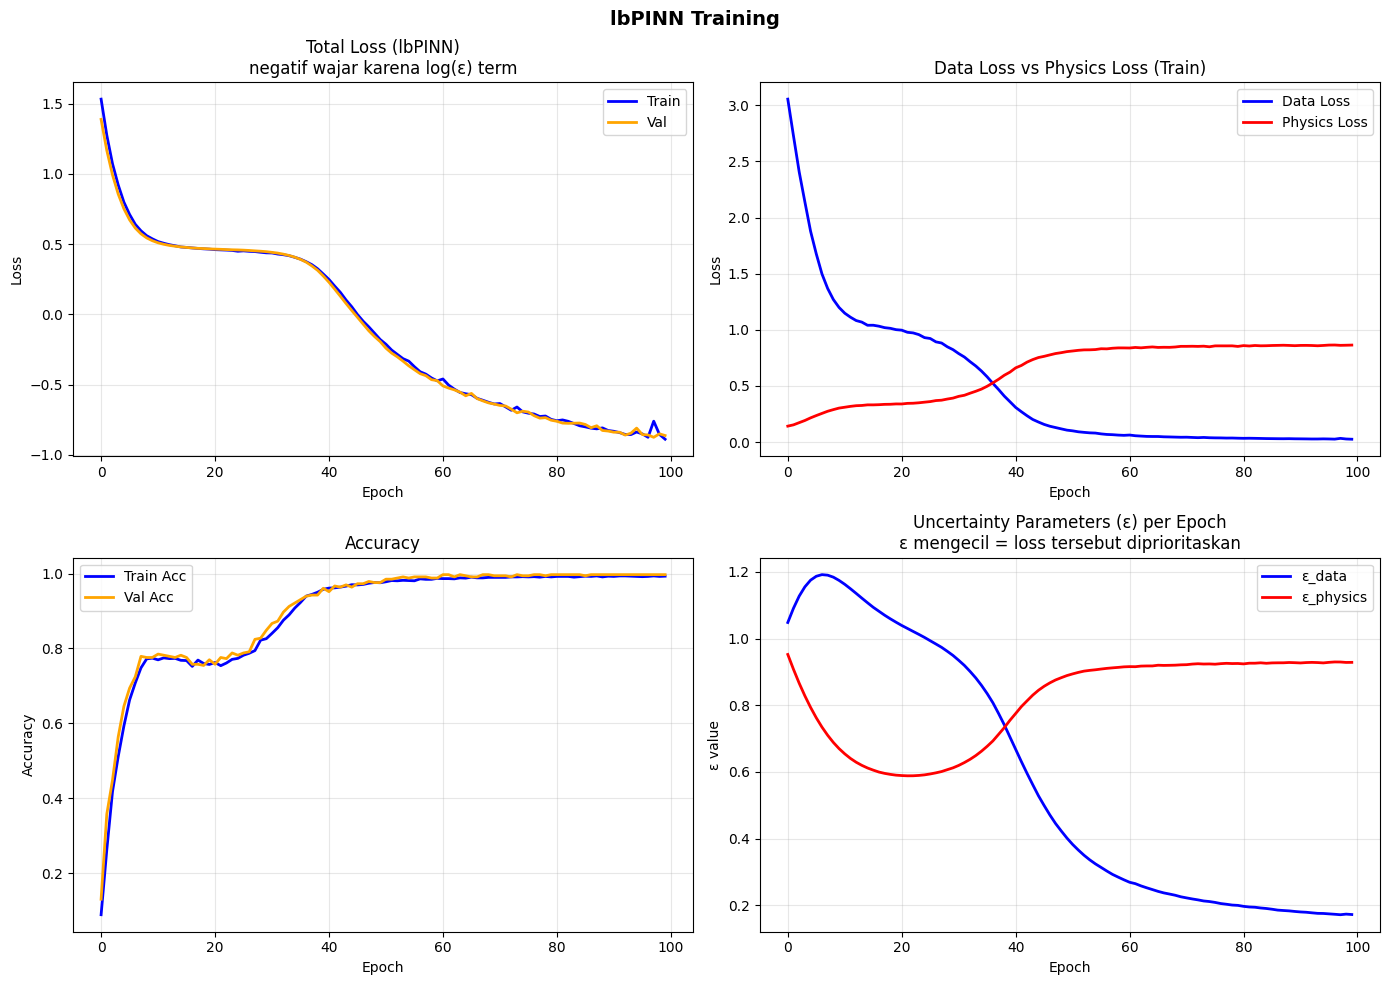

✅ Training curve disimpan


In [50]:
# ============================================================
# CELL 8: Plot Training Curve
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Loss
axes[0,0].plot(history['train_total'], label='Train',
               color='blue', linewidth=2)
axes[0,0].plot(history['val_total'],   label='Val',
               color='orange', linewidth=2)
axes[0,0].set_title('Total Loss (lbPINN)\n'
                     'negatif wajar karena log(ε) term')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Data Loss vs Physics Loss
axes[0,1].plot(history['train_data'],    label='Data Loss',
               color='blue', linewidth=2)
axes[0,1].plot(history['train_physics'], label='Physics Loss',
               color='red', linewidth=2)
axes[0,1].set_title('Data Loss vs Physics Loss (Train)')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Accuracy
axes[1,0].plot(history['train_acc'], label='Train Acc',
               color='blue', linewidth=2)
axes[1,0].plot(history['val_acc'],   label='Val Acc',
               color='orange', linewidth=2)
axes[1,0].set_title('Accuracy')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Epsilon trend
axes[1,1].plot(history['eps_data'],    label='ε_data',
               color='blue', linewidth=2)
axes[1,1].plot(history['eps_physics'], label='ε_physics',
               color='red', linewidth=2)
axes[1,1].set_title('Uncertainty Parameters (ε) per Epoch\n'
                     'ε mengecil = loss tersebut diprioritaskan')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('ε value')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('lbPINN Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/03_lbpinn_training_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curve disimpan")

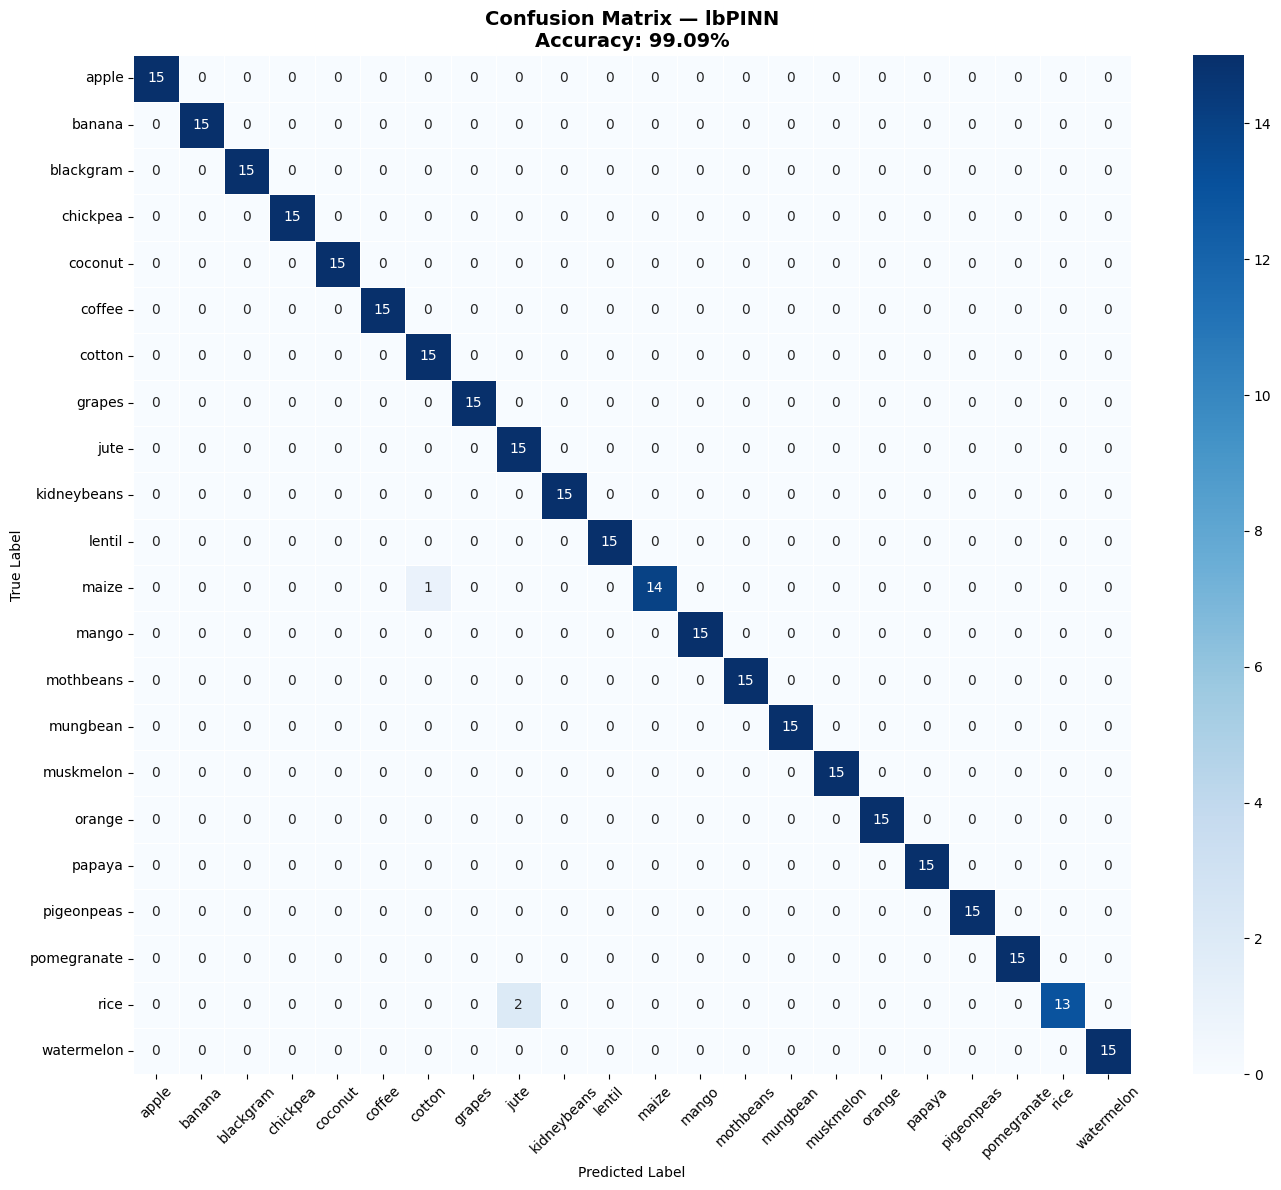

✅ Confusion matrix disimpan


In [51]:
# ============================================================
# CELL 9: Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(f'Confusion Matrix — lbPINN\n'
             f'Accuracy: {acc*100:.2f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('results/03_lbpinn_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

In [52]:
# ============================================================
# CELL 10: Simpan Model dan Hasil
# ============================================================

model_lbpinn.save('models/lbpinn.keras')

results_lbpinn = {
    'history' : history,
    'metrics' : {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_score' : f1,
    },
    'confusion_matrix'  : cm,
    'y_true'            : y_true,
    'y_pred'            : y_pred_l,
    'final_eps_data'    : history['eps_data'][-1],
    'final_eps_physics' : history['eps_physics'][-1],
    'config'            : {
        'architecture': f'{INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}',
        'epochs'      : EPOCHS,
        'batch_size'  : BATCH_SIZE,
        'lr'          : LR,
        'eps_init'    : 1.0,
    }
}

with open('session/results_lbpinn.pkl', 'wb') as f:
    pickle.dump(results_lbpinn, f)

print("✅ Model tersimpan  : models/lbpinn.keras")
print("✅ Hasil tersimpan  : session/results_lbpinn.pkl")
print(f"\nRingkasan:")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  ε_data akhir    : {history['eps_data'][-1]:.4f}")
print(f"  ε_physics akhir : {history['eps_physics'][-1]:.4f}")
print(f"  w_data akhir    : "
      f"{1/(2*history['eps_data'][-1]**2):.2f}")
print(f"  w_physics akhir : "
      f"{1/(2*history['eps_physics'][-1]**2):.2f}")

✅ Model tersimpan  : models/lbpinn.keras
✅ Hasil tersimpan  : session/results_lbpinn.pkl

Ringkasan:
  Accuracy    : 99.09%
  ε_data akhir    : 0.1721
  ε_physics akhir : 0.9286
  w_data akhir    : 16.88
  w_physics akhir : 0.58
